## This notebook aims to compute fidelity and trace distance between GS/2nd_EX of critical Ising model under Z dephasing in the perturbative regime: qN<<1. We can truncate the basis to 2N+2 rank. The Gram matrix is computed exactly in terms of free fermion correlation matrix

In [2]:
using LinearAlgebra

In [3]:
function get_corr_mat(N)
    ## correlation matrix for critical Ising model, using analytical result via Fourier https://arxiv.org/pdf/1901.06439 (App.D)
    p(n) = 2pi/(2*N)*(n+1/2); #n = 0,1,... N-1
    GS_corr(i,j) = 1/(2*N)*sum([cis(-(i-j)*p(n)) for n in 0:N-1]); ## <f_i f_j>, i,j = 1, .. 2N, majorana sites
    excited_corr(i,j) = 1/(2*N)*(sum([cis(-(i-j)*p(n)) for n in 1:N-2]) + sum([cis((i-j)*p(n)) for n in [0,N-1]]))  ## For 2nd excited state
    GS_corr_mat = zeros(ComplexF64, 2*N, 2*N)
    excited_corr_mat = zeros(ComplexF64, 2*N, 2*N)
    for i in 1:2*N
        for j in 1:2*N
            GS_corr_mat[i,j] = GS_corr(i,j)
            excited_corr_mat[i,j] = excited_corr(i,j)
        end
    end
    return GS_corr_mat, excited_corr_mat
end

get_corr_mat (generic function with 1 method)

In [4]:
function gram_from_corr_mat(corr_mat, N)
    ## |psi>, Z_i|psi> overlaps, assuming translation invariance
    ## i.e. <psi|Z|psi> and <psi|Z_i Z_j|psi>
    Z_one_pt = 2*imag(corr_mat[1,2])
    Z_two_pts = zeros(N-1)
    for dist in 1:N-1
        site = dist + 1
        Z_two_pt = real(-4*(corr_mat[1,2]^2 - corr_mat[1,2*site-1] * corr_mat[2, 2*site] + corr_mat[1,2*site] * corr_mat[2, 2*site-1]))
        Z_two_pts[dist] = Z_two_pt
    end
    gram_mat = zeros(N+1,N+1)
    for i in 1:N+1
        for j in i+1:N+1
            if(i==1)
                gram_mat[i,j] = Z_one_pt
            else
                dist = j-i
                gram_mat[i,j] = Z_two_pts[dist]
            end
        end
    end
    gram_mat = gram_mat + gram_mat'
    for i in 1:N+1
        gram_mat[i,i] = 1
    end
    return gram_mat
end 

gram_from_corr_mat (generic function with 1 method)

In [18]:
function cross_gram_from_corr_mat(GS_corr_mat,N)
    ## Transition amplitude <gs|Z|ex> and <gs|Z_i Z_j|ex>
    p(n) = 2pi/(2*N)*(n+1/2); #n = 0,1,... N-1
    T0 = (2/N)*cos(p(0)) # analytical result (eq. D42)
    Tex = zeros(N-1)
    for dist in 1:N-1
        j = dist + 1
        T_132456 = -2/N * cis(p(N-1)*1 + p(0)*2) * GS_corr_mat[2*j-1,2*j] # odd
        T_132546 = -2/N * cis(p(N-1)*1 + p(0)*(2*j-1)) * GS_corr_mat[2,2*j] # even
        T_132645 = -2/N * cis(p(N-1)*1 + p(0)*(2*j)) * GS_corr_mat[2,2*j-1] # odd
        T_142356 = -2/N * cis(p(N-1)*2 + p(0)*1) * GS_corr_mat[2*j-1,2*j] # even
        T_142536 = -2/N * cis(p(N-1)*2 + p(0)*(2*j-1)) * GS_corr_mat[1,2*j] # odd
        T_142635 = -2/N * cis(p(N-1)*2 + p(0)*(2*j)) * GS_corr_mat[1,2*j-1] # even

        T_152346 = -2/N * cis(p(N-1)*(2*j-1) + p(0)*1) * GS_corr_mat[2,2*j] # odd
        T_152436 = -2/N * cis(p(N-1)*(2*j-1) + p(0)*2) * GS_corr_mat[1,2*j] # even
        T_152634 = -2/N * cis(p(N-1)*(2*j-1) + p(0)*(2*j)) * GS_corr_mat[1,2] #odd
        T_162345 = -2/N * cis(p(N-1)*(2*j) + p(0)*1) * GS_corr_mat[2,2*j-1] # even
        T_162435 = -2/N * cis(p(N-1)*(2*j) + p(0)*2) * GS_corr_mat[1,2*j-1] # odd
        T_162534 = -2/N * cis(p(N-1)*(2*j) + p(0)*(2*j-1)) * GS_corr_mat[1,2] # even

        T_even = T_132546+T_142356+T_142635+T_152436+T_162345+T_162534
        T_odd = T_132456+T_132645+T_142536+T_152346+T_152634+T_162435

        Tex[dist] = -imag(T_even - T_odd) ## This comes from 12 possible Wick contractions
    end
    cross_gram = zeros(N+1,N+1) # diagonal = 0
    for i in 1:N+1
        for j in i+1:N+1
            if(i==1)
                cross_gram[i,j] = T0 # <ex|Z|gs>
            else
                dist = j-i
                cross_gram[i,j] = Tex[dist]
            end
        end
    end
    cross_gram = cross_gram + cross_gram'
    return cross_gram
end

cross_gram_from_corr_mat (generic function with 1 method)

In [19]:
function get_total_gram_mat(N)
    ## 2N+2 basis vectors |psi0>, Z_i|psi0>, |psi2>, Z_i|psi2>
    ## compute Gram matrix (Real, symmetric)
    GS_corr_mat, excited_corr_mat = get_corr_mat(N)
    gram_mat_GS = gram_from_corr_mat(GS_corr_mat,N) 
    gram_mat_excited = gram_from_corr_mat(excited_corr_mat,N);
    cross_gram = cross_gram_from_corr_mat(GS_corr_mat,N);
    total_gram = [[gram_mat_GS cross_gram];[cross_gram' gram_mat_excited]];
    return total_gram
end

get_total_gram_mat (generic function with 1 method)

In [20]:
function sqrt_mat(A)
    ## A = Hermitian
    D,U = eigen((A+A')/2)
    sqrtA = U * diagm(sqrt.(abs.(D))) * U'
    return sqrtA
end

function compute_fidelity(rho1,rho2)
    S = svdvals(sqrt_mat(rho1)*sqrt_mat(rho2))
    f = sum(S)
    return f
end


function compute_trace_distance(rho1,rho2)
    S = svdvals(rho1-rho2)
    f = sum(S)/2
    return f
end

compute_trace_distance (generic function with 1 method)

In [32]:
q = 0.00001;
N = 16
rho0 = diagm(vcat(vcat([1-(q*N)/2], (q/2)*ones(N)...),zeros(N+1)...));
rho2 = diagm(vcat(zeros(N+1),vcat([1-(q*N)/2], (q/2)*ones(N)...)));

In [33]:
total_gram = get_total_gram_mat(N)
D,U = eigen(total_gram);
M = diagm(sqrt.(D))*U' #such that M'M = G
rho0_in_basis = M*rho0*M'
rho2_in_basis = M*rho2*M';

In [34]:
F = compute_fidelity(rho0_in_basis,rho2_in_basis);
T = compute_trace_distance(rho0_in_basis,rho2_in_basis);
F_lb = sqrt(tr(rho0_in_basis*rho2_in_basis));
F_ub = sqrt(1-T^2);
F_lb, F, F_ub # lower bound, fidelity, upper bound

(0.0015735153288129677, 0.002237694100761003, 0.003210579162729255)

In [35]:
function run_main(N;q=0.00001)
    rho0 = diagm(vcat(vcat([1-(q*N)/2], (q/2)*ones(N)...),zeros(N+1)...));
    rho2 = diagm(vcat(zeros(N+1),vcat([1-(q*N)/2], (q/2)*ones(N)...)));
    total_gram = get_total_gram_mat(N)
    D,U = eigen(total_gram);
    M = diagm(sqrt.(D))*U' #such that M'M = G
    rho0_in_basis = M*rho0*M'
    rho2_in_basis = M*rho2*M';
    F = compute_fidelity(rho0_in_basis,rho2_in_basis);
    T = compute_trace_distance(rho0_in_basis,rho2_in_basis);
    F_lb = sqrt(tr(rho0_in_basis*rho2_in_basis));
    F_ub = sqrt(1-T^2);
    return F_lb, F, F_ub 
end

run_main (generic function with 1 method)

In [36]:
Ns = [16, 32, 48, 64, 80, 96];
F_lbs = zeros(length(Ns))
Fs = zeros(length(Ns))
F_ubs = zeros(length(Ns))
for i in 1:length(Ns)
    N = Ns[i]
    @time F_lb, F, F_ub = run_main(N)
    F_lbs[i] = F_lb
    Fs[i] = F
    F_ubs[i] = F_ub
end

  0.209208 seconds (89.15 k allocations: 5.086 MiB, 97.03% compilation time)
  0.032249 seconds (38.11 k allocations: 6.767 MiB, 20.43% gc time)
  0.153757 seconds (83.80 k allocations: 19.792 MiB, 4.84% gc time)
  0.294916 seconds (147.47 k allocations: 43.503 MiB, 2.34% gc time)
  0.297274 seconds (229.05 k allocations: 81.084 MiB, 4.80% gc time)
  0.597029 seconds (328.55 k allocations: 135.726 MiB, 4.05% gc time)


In [40]:
using Plots

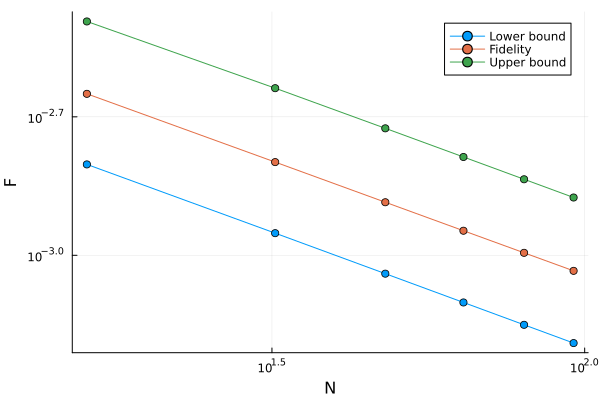

In [45]:
plot(Ns, F_lbs, xaxis=:log, yaxis=:log,label="Lower bound",xlabel="N",ylabel="F",linestyle=:solid,marker=:circle)
plot!(Ns, Fs, xaxis=:log, yaxis=:log,label="Fidelity",xlabel="N",ylabel="F",linestyle=:solid,marker=:circle)
plot!(Ns, F_ubs, xaxis=:log, yaxis=:log,label="Upper bound",xlabel="N",ylabel="F",linestyle=:solid,marker=:circle)

In [46]:
savefig("perturbative.pdf")

"C:\\Users\\yijia\\Research\\Working\\MPDO fidelity\\V20250716\\perturbative.pdf"